In [1]:
import numpy as np
from scipy.integrate import quad, tplquad
import vtk
import pyvista as pv

from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve

import matplotlib.pyplot as plt

## Problem description

The goal is to solve the Eikonal equation in deformable solids:
$$
\lvert \nabla \phi \lvert - 1 = 0
$$ 

Where $\phi$ is the distance function with boundary value equal to 0 on the triangular faces of the deformable solid facing the 
exterior. 

This equation will be solved here with the Heat method. The first step consists in solving the following heat equation: 
$$
\begin{aligned}
&\frac{\partial u}{\partial t} - \Delta u = 0 \\ 
&u(t = 0) = 0\; \mathrm{on}\; \Omega \\
&u(t = 0) = 1\; \mathrm{on}\; \partial \Omega \\
\end{aligned}
$$

We will solve this equation using the Garlekin method of weighted residuals. The weak form of the Heat equation is given by:

$$
\int_{\Omega}  \frac{\partial u}{\partial t} \, \phi_j \;  d\Omega -  \int_{\Omega} \Delta u \phi_j \; d\Omega = 0
$$ where $\phi_j$ is a test function.

After applying Green's first identity, we obtain:

$$
\int_{\Omega}  \frac{\partial u}{\partial t} \, \phi_j \;  d\Omega  + \int_{\Omega} \nabla u \cdot \nabla \phi_j \; d\Omega  = \int_{\Gamma} \phi_j \nabla u \cdot n \;  d\Gamma\
$$

The Neumann boundary term is equal to 0 in this case. 

Now we expand $u(t, x, y)$ in terms of a finite element basis functions 
$$
u(t, x, y) = \sum_{i} \alpha_i(t) \cdot \phi_i(x,y)
$$ 

$$
\sum_{i} \frac{d \alpha_i}{d t} \, \int_{\Omega}   \phi_i \phi_j \;  d\Omega  + \sum_{i} \alpha_i \int_{\Omega} \nabla  \phi_i \cdot \nabla \phi_j \; d\Omega  = 0
$$

We can write this in matrix form as:
$$
M \frac{d \vec{\alpha}}{d t} + K \vec{\alpha} = 0
$$

We solve this system of equations over time with the backward Euler method (Implicit time integrator):

$$ 
M \frac{\vec{\alpha}^{n+1} -  \vec{\alpha}^{n} }{h} +  K \vec{\alpha}^{n+1} = 0
$$ where h is the time step.

$$
M \vec{\alpha}^{n+1} + h K \vec{\alpha}^{n+1} = M \vec{\alpha}^{n} 
$$

$$
\left[ M +  h K \right] \vec{\alpha}^{n+1} = M \vec{\alpha}^{n} 
$$





To interpolate $u$ in our triangular elements, we will use a first order Lagrange basis function. 
The basis functions in the element are given by:

$$\phi_1(u,v,w) = 1-u-v-w$$
$$\phi_2(u,v,w) = u$$
$$\phi_3(u,v,w) = v$$
$$\phi_4(u,v,w) = w$$

Where $u$, $v$, and $w$ are the barycentric coordinates of a point in the element.

In [2]:
class Face: 
    def __init__(self, vertices, cell_1 = -1, cell_2 = -1):
        self.vertices   = vertices
        self.cell_1     = cell_1
        self.cell_2     = cell_2

    def add_cell(self, cell):
        if self.cell_1 == None:
            self.cell_1 = cell
        else:
            self.cell_2 = cell

    def is_boundary_face(self):
        return self.cell_2 == -1
    
    def __hash__(self):
        return tuple(sorted(self.vertices))
    
    def __eq__(self, other):
        return self.__hash__() == other.__hash__()

In [3]:
reader = vtk.vtkUnstructuredGridReader()
reader.SetFileName("tetrahedralized_cube_high_res.vtk")
reader.Update()
u_grid = reader.GetOutput()

# Collect the positions of the nodes
n_nodes = u_grid.GetNumberOfPoints()
node_lst = [u_grid.GetPoint(i) for i in range(n_nodes)]
point_ar = np.array(node_lst)
n_vertices = point_ar.shape[0]

cell_lst = []
#Loop over the cells in the VTK mesh (not all vtk cells are tetrahedra)
for cell_id in range(u_grid.GetNumberOfCells()):

    cell = u_grid.GetCell(cell_id)
    n_cell_pts = cell.GetNumberOfPoints()

    #If the cell is a tetrahedron
    if n_cell_pts == 4:

        # Get the points of the cell
        cell_lst.append([cell.GetPointId(i) for i in range(n_cell_pts)])

# Store the faces of the mesh in this dictionary
face_dic = {}

# Loop over the tetrahedra in the mesh
for cell_id, cell_pts in enumerate(cell_lst):
    face_0 = [cell_pts[0], cell_pts[1], cell_pts[2]]
    face_1 = [cell_pts[0], cell_pts[1], cell_pts[3]]
    face_2 = [cell_pts[0], cell_pts[2], cell_pts[3]]
    face_3 = [cell_pts[1], cell_pts[2], cell_pts[3]]

    #Create the faces
    face_0 = Face(face_0, cell_id)
    face_1 = Face(face_1, cell_id)
    face_2 = Face(face_2, cell_id)
    face_3 = Face(face_3, cell_id)

    # Check if the faces are already in the dictionary
    face_0_dic = face_dic.get(face_0.__hash__(), None)
    face_1_dic = face_dic.get(face_1.__hash__(), None)
    face_2_dic = face_dic.get(face_2.__hash__(), None)
    face_3_dic = face_dic.get(face_3.__hash__(), None)

    if face_0_dic is None: face_dic[face_0.__hash__()] = face_0
    else: face_0_dic.add_cell(cell_id)

    if face_1_dic is None: face_dic[face_1.__hash__()] = face_1
    else: face_1_dic.add_cell(cell_id)
        
    if face_2_dic is None: face_dic[face_2.__hash__()] = face_2
    else: face_2_dic.add_cell(cell_id)

    if face_3_dic is None: face_dic[face_3.__hash__()] = face_3
    else: face_3_dic.add_cell(cell_id)


# The point IDs of the tetrahedral cells
cell_ar = np.array(cell_lst)
n_cells = cell_ar.shape[0]

# The point IDs of the faces
face_ar =       np.array([f.vertices for f in face_dic.values()])
n_faces = face_ar.shape[0]

# The cell sharing each face
face_cell_ar =  np.array([[f.cell_1, f.cell_2] for f in face_dic.values()])

# Store for each tetrahedron the faces that it contains
cell_face_lst = [[] for _ in range(cell_ar.shape[0])]

for face_id, (cell_1, cell_2) in enumerate(face_cell_ar):
    if cell_1 != -1: cell_face_lst[cell_1].append(face_id)
    if cell_2 != -1: cell_face_lst[cell_2].append(face_id)

cell_face_ar = np.array(cell_face_lst)

# We need to collect all the boundary points
boundary_faces_idx = np.argwhere(face_cell_ar[:, 1] == -1).flatten()

# Collect the points of the boundary faces
boundary_points = np.unique(face_ar[boundary_faces_idx].flatten())
boundary_point_mask = np.zeros(n_vertices, dtype=bool)
boundary_point_mask[boundary_points] = True

In [4]:
# Compute the minimum edge length in the mesh
p1_ar, p2_ar, p3_ar = point_ar[face_ar[:, 0]], point_ar[face_ar[:, 1]], point_ar[face_ar[:, 2]] 

edge_ar = np.vstack([
    p1_ar - p2_ar,
    p2_ar - p3_ar,
    p1_ar - p3_ar,
])

min_edge_length = np.linalg.norm(edge_ar, axis=1).min()

In [5]:
def basis_fn_1(u, v, w): return 1 - u - v - w
def basis_fn_2(u, v, w): return u
def basis_fn_3(u, v, w): return v
def basis_fn_4(u, v, w): return w

grad_basis_fn_1 = np.array([-1, -1, -1])
grad_basis_fn_2 = np.array([1,   0,  0])
grad_basis_fn_3 = np.array([0,   1,  0])
grad_basis_fn_4 = np.array([0,   0,  1])

reference_basis_fn_lst =      [basis_fn_1, basis_fn_2, basis_fn_3, basis_fn_4]
reference_grad_basis_fn_lst = [grad_basis_fn_1, grad_basis_fn_2, grad_basis_fn_3, grad_basis_fn_4]
n_local_basis_fn = len(reference_basis_fn_lst)

In [6]:
#Integrate the product of the basis functions over the reference triangle

#This is the mass matrix for the reference triangle
M_reference = np.zeros((n_local_basis_fn, n_local_basis_fn))

for i in range(n_local_basis_fn):
    for j in range(i, n_local_basis_fn):
        
        M_reference[i, j] = tplquad(
            lambda u, v, w: reference_basis_fn_lst[i](u, v, w) * reference_basis_fn_lst[j](u, v, w), 
            0, 1, 
            0, lambda u: 1 - u, 
            0, lambda u, v: 1 - u - v
        )[0]
        
        M_reference[j, i] = M_reference[i, j] 

In [7]:
# For each triangle in the mesh we need to compute the Jacobian of the map from global to local coordinates
p0_ar = point_ar[cell_ar[:, 0]]
p1_ar = point_ar[cell_ar[:, 1]]
p2_ar = point_ar[cell_ar[:, 2]]
p3_ar = point_ar[cell_ar[:, 3]]

p3_to_p0_ar = p1_ar - p0_ar
p3_to_p1_ar = p2_ar - p0_ar
p3_to_p2_ar = p3_ar - p0_ar

# Contruct the Jacobian matrices of the map from the reference tetrhedron to the physical tetrahedron for each cell
jacobian_ar = np.zeros((n_cells, 3, 3))

jacobian_ar[:, 0, 0] = p3_to_p0_ar[:, 0]
jacobian_ar[:, 0, 1] = p3_to_p0_ar[:, 1]
jacobian_ar[:, 0, 2] = p3_to_p0_ar[:, 2]

jacobian_ar[:, 1, 0] = p3_to_p1_ar[:, 0]
jacobian_ar[:, 1, 1] = p3_to_p1_ar[:, 1]
jacobian_ar[:, 1, 2] = p3_to_p1_ar[:, 2]

jacobian_ar[:, 2, 0] = p3_to_p2_ar[:, 0]
jacobian_ar[:, 2, 1] = p3_to_p2_ar[:, 1]
jacobian_ar[:, 2, 2] = p3_to_p2_ar[:, 2]

#Compute the determinant of each Jacobian matrix
det_jacobian_ar = np.abs(np.linalg.det(jacobian_ar))

# Invert the Jacobian matrices
inv_jacobian_ar = np.linalg.inv(jacobian_ar)

#This list stores the product of the gradient of the basis functions with the inverse of the Jacobian
local_grad_basis_fn_lst = [np.dot(inv_jacobian_ar, reference_grad_basis_fn_lst[i]) for i in range(n_local_basis_fn)]

#Now we compute the local mass matrix for each triangle
local_stiffness_matrix_ar   = np.zeros((n_cells, n_local_basis_fn, n_local_basis_fn))
local_mass_matrix_ar        = np.zeros((n_cells, n_local_basis_fn, n_local_basis_fn))


#Compute the local stiffness and mass matrices
for i in range(n_local_basis_fn):
    for j in range(i, n_local_basis_fn):
 
        #Stiffness matrix
        local_stiffness_matrix_ar[:, i, j] = (1.0/6.0) * det_jacobian_ar * np.sum(local_grad_basis_fn_lst[i] * local_grad_basis_fn_lst[j], axis = 1)
        local_stiffness_matrix_ar[:, j, i] = local_stiffness_matrix_ar[:, i, j]

        #Mass matrix
        local_mass_matrix_ar[:, i, j] = det_jacobian_ar * M_reference[i, j]
        local_mass_matrix_ar[:, j, i] = local_mass_matrix_ar[:, i, j] 


#Now we need to assemble the global stiffness matrix
row_id = np.repeat(cell_ar, n_local_basis_fn).flatten()
col_id = np.tile(cell_ar, n_local_basis_fn).flatten()


stiffness_data   = local_stiffness_matrix_ar.flatten()
mass_data = local_mass_matrix_ar.flatten()

# Create the sparse global stiffness matrix
global_stiffness_matrix = csc_matrix((stiffness_data.flatten(), (row_id, col_id)), shape=(n_vertices, n_vertices))
global_mass_matrix =      csc_matrix((mass_data.flatten(), (row_id, col_id)), shape=(n_vertices, n_vertices))

global_stiffness_matrix.sum_duplicates()
global_mass_matrix.sum_duplicates()

/home/steve/Documents/Miscellaneous/FEM/fem_env/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/steve/Documents/Miscellaneous/FEM/fem_env/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(
MESA-LOADER: failed to open zink: /opt/amdgpu/lib/x86_64-linux-gnu/dri/zink_dri.so: cannot open shared object file: No such file or directory (search paths /opt/amdgpu/lib/x86_64-linux-gnu/dri, suffix _dri)
failed to load driver: zink


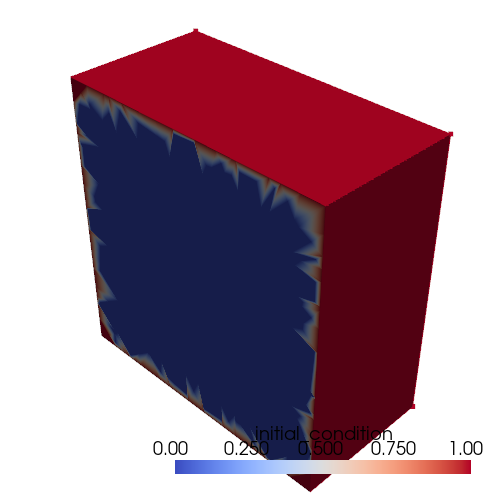

In [8]:
initial_condition = boundary_point_mask.astype(int)

pv_before_mesh = pv.wrap(u_grid)
pv_before_mesh.point_data["initial_condition"] = initial_condition
pv_before_mesh = pv_before_mesh.clip(normal=(1, 0, 0), origin=(0.5, 0.5, 0.5))  # Plane normal = (1, 0, 0)


# Create a plotter for Jupyter Notebooks
pv.start_xvfb()  # Needed for some environments (e.g., remote servers)
plotter = pv.Plotter(notebook=True, window_size=(500, 500))
plotter.add_mesh(pv_before_mesh, scalars="initial_condition", cmap="coolwarm", clim= [0,1])
plotter.show()

In [9]:
#Compute the update matrix
time_step = min_edge_length**2

# We form the lhs matrix
lhs_matrix = global_mass_matrix + time_step * global_stiffness_matrix
lhs_matrix_with_BC = lhs_matrix[~boundary_point_mask, :][:, ~boundary_point_mask]

# Form the rhs vector
rhs_vector = (global_mass_matrix - lhs_matrix) @ boundary_point_mask.astype(int)
rhs_vector_with_BC = rhs_vector[~boundary_point_mask]


#Advance the system by one time step
fem_solution_interior_point = spsolve(lhs_matrix_with_BC, rhs_vector_with_BC)

fem_solution = np.ones(n_vertices)
fem_solution[~boundary_point_mask] = fem_solution_interior_point

/home/steve/Documents/Miscellaneous/FEM/fem_env/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/steve/Documents/Miscellaneous/FEM/fem_env/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(
MESA-LOADER: failed to open zink: /opt/amdgpu/lib/x86_64-linux-gnu/dri/zink_dri.so: cannot open shared object file: No such file or directory (search paths /opt/amdgpu/lib/x86_64-linux-gnu/dri, suffix _dri)
failed to load driver: zink


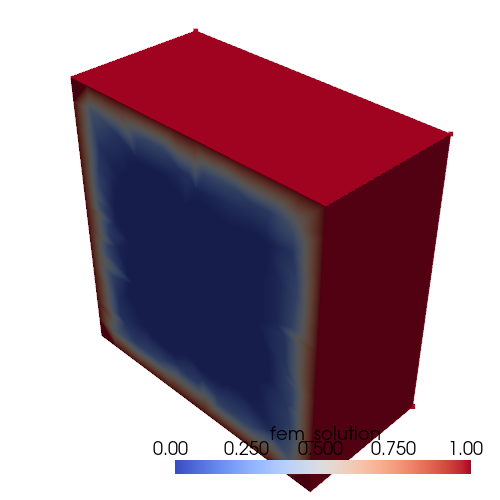

In [10]:
pv_after_mesh = pv.wrap(u_grid)
pv_after_mesh.point_data["fem_solution"] = fem_solution
pv_after_mesh = pv_after_mesh.clip(normal=(1, 0, 0), origin=(0.5, 0.5, 0.5))  # Plane normal = (1, 0, 0)

# Create a plotter for Jupyter Notebooks
pv.start_xvfb()  # Needed for some environments (e.g., remote servers)
plotter = pv.Plotter(notebook=True, window_size=(500, 500))
plotter.add_mesh(pv_after_mesh, scalars="fem_solution", cmap="coolwarm", clim= [0,1])
plotter.show()


We need to compute the gradient of the heat and then normalize it. The heat at any point in an element is given by:
$$
u(x,y,z,t) = \alpha_1(t) \phi_1(x,y,z) + \alpha_2(t) \phi_2(x,y,z) + \alpha_3(t) \phi_3(x,y,z) + \alpha_4(t) \phi_4(x,y,z)
$$

The gradient of the heat is therefore given by:
$$
\nabla u = \begin{bmatrix}
\partial_x \phi_1 & \partial_x \phi_2 & \partial_x \phi_3 & \partial_x \phi_4 \\
\partial_y \phi_1 & \partial_y \phi_2 & \partial_y \phi_3 & \partial_y \phi_4 \\
\partial_z \phi_1 & \partial_z \phi_2 & \partial_z \phi_3 & \partial_z \phi_4 \\
\end{bmatrix} \begin{bmatrix}
\alpha_1(t) \\
\alpha_2(t) \\
\alpha_3(t) \\
\alpha_4(t) \\
\end{bmatrix}
$$

The shape functions are given by:
$$ 
\begin{bmatrix}
\phi_1(X)\\
\phi_2(X)\\
\phi_3(X)\\
\phi_4(X)\\
\end{bmatrix} =  


\begin{bmatrix}
1\\
0\\
0\\
0\\
\end{bmatrix} 
+
\underbrace{
\begin{bmatrix}
& & & -\vec{1}^{T} \; T^{-1} & & & \\
-&-&-&-&-&-& \\
& & & & & & \\
& & &T^{-1}& & & \\
& & & & & & \\
\end{bmatrix}}_{=D \;(4 \times 3)}


\underbrace{
(X - X_0)}_{(3 \times 1)}
$$

We can therefore obtain the gradient of the basis function with the formula:
$$
\begin{bmatrix}
\phi_1(X)\\
\phi_2(X)\\
\phi_3(X)\\
\phi_4(X)\\
\end{bmatrix} 

\begin{bmatrix}
\partial_x  & \partial_y & \partial_z \\
\end{bmatrix} = D 
$$

Therefore the gradient of the heat is given by:
$$
\nabla u = D^T \begin{bmatrix}
\alpha_1(t) \\
\alpha_2(t) \\
\alpha_3(t) \\
\alpha_4(t) \\
\end{bmatrix}
$$





In [11]:
# Compute the T and D matrices for all the tetrhedra in the mesh
x0_ar = point_ar[cell_ar[:, 0]]
x1_ar = point_ar[cell_ar[:, 1]]
x2_ar = point_ar[cell_ar[:, 2]]
x3_ar = point_ar[cell_ar[:, 3]]

#Compute the T matrix for all the tetrahedra
T = np.column_stack([x1_ar - x0_ar, x2_ar - x0_ar, x3_ar - x0_ar]).reshape(-1, 3, 3)
T = np.transpose(T, (0, 2, 1))

#Compute the inverse of the T matrix
T_inv = np.linalg.inv(T)

#Compute the D matrix for all the tetrahedra
D = np.hstack([-np.sum(T_inv, axis=1)[:, np.newaxis], T_inv])
D_T = np.transpose(D, (0, 2, 1))

# Get the heat value for each node of each tetrahedron
heat_ar = fem_solution[cell_ar]
heat_ar = heat_ar.reshape(-1, 4, 1)

# Compute the heat gradient for each tetrahedron
heat_gradient_ar = np.matmul(D_T, heat_ar)
heat_gradient_ar = heat_gradient_ar.reshape(-1, 3)

For the heat method we now need to normalize the gradient of the heat
$$
\Psi = - \nabla u / \lvert \nabla u \lvert
$$

And then solve the Poisson problem:
$$
\Delta \phi = \nabla \cdot \Psi 
$$

The value of $\Psi$ in the element is given by:
$$
\Psi(X)  = \underbrace{
\begin{bmatrix}
 \mid& \mid&  \mid& \mid  \\
 \Psi_1&  \Psi_2&  \Psi_3&  \Psi_4 \\
 \mid&  \mid&  \mid& \mid \\
\end{bmatrix}}_{(3 \times 4)} \cdot

\begin{bmatrix}
\phi_0(X)\\
\phi_1(X)\\
\phi_2(X)\\
\phi_3(X)\\
\end{bmatrix}
$$

$$
\Psi(X) = \vec{\Psi_0} +

\underbrace{
\begin{bmatrix}
 \mid& \mid&  \mid& \mid  \\
 \Psi_0&  \Psi_1&  \Psi_2&  \Psi_3 \\
 \mid&  \mid&  \mid& \mid \\
\end{bmatrix}

\begin{bmatrix}
& & & -\vec{1}^{T} \; T^{-1} & & & \\
-&-&-&-&-&-& \\
& & & & & & \\
& & &T^{-1}& & & \\
& & & & & & \\
\end{bmatrix}}_{=P \; (3 \times 3)}

\underbrace{
(X - X_0)}_{(3 \times 1)}
$$

The divergence of $\Psi$ is given by:
$$


\nabla  \cdot \Psi = 

\nabla  \cdot


\begin{bmatrix}
 \mid& \mid&  \mid  \\
 P_1&  P_2&  P_3 \\
 \mid&  \mid&  \mid \\
\end{bmatrix} 
\begin{bmatrix}
x \\
y \\
z \\
\end{bmatrix} = \nabla  \cdot \left[xP1 + yP2 + zP3\right]

= P1_x + P2_y + P3_z = \mathrm{tr}(P)
$$

The divergence is constant in each tetrahedron but vary from one to the other, to get the divergence at each node we average the divergence of the tetrahedra sharing the node.


In [12]:
# Normalize the heat gradient
psi_ar = -heat_gradient_ar / np.linalg.norm(heat_gradient_ar, axis=1)[:, np.newaxis]
psi_ar = np.nan_to_num(psi_ar)

# Compute the value of psi in each tetrhedron
psi_cell_ar = np.transpose(psi_ar[cell_ar], (0,2,1))

# Compute the P matrices 
P_ar = np.matmul(psi_cell_ar, D)

# Compute the trace of the P matrices
div_cell_psi = np.trace(P_ar, axis1=1, axis2=2)

# Compute the cell volume
cell_volume_ar = np.abs(np.linalg.det(T))/6.0

/tmp/ipykernel_26062/98943653.py:2: RuntimeWarning: invalid value encountered in divide
  psi_ar = -heat_gradient_ar / np.linalg.norm(heat_gradient_ar, axis=1)[:, np.newaxis]


In [19]:
# Create an incidence matrix that maps the quantities computed at the cell level to the vertices
row_id = cell_ar.flatten()
col_id = np.repeat(np.arange(n_cells), 4)
data = np.ones(n_cells * 4)
cell_to_node_incidence_matrix = csc_matrix((data, (row_id, col_id)), shape=(n_vertices, n_cells))


In [20]:
# Compute the average divergence at each node
sum_div_node_psi        = cell_to_node_incidence_matrix @ (div_cell_psi * cell_volume_ar)
sum_node_vol_coverage   = cell_to_node_incidence_matrix @ cell_volume_ar
div_node_psi = sum_div_node_psi / sum_node_vol_coverage

/home/steve/Documents/Miscellaneous/FEM/fem_env/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/steve/Documents/Miscellaneous/FEM/fem_env/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(
MESA-LOADER: failed to open zink: /opt/amdgpu/lib/x86_64-linux-gnu/dri/zink_dri.so: cannot open shared object file: No such file or directory (search paths /opt/amdgpu/lib/x86_64-linux-gnu/dri, suffix _dri)
failed to load driver: zink


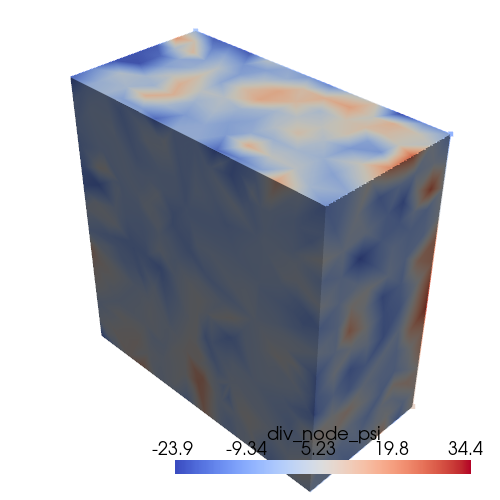

In [21]:
pv_div_mesh = pv.wrap(u_grid)
pv_div_mesh.point_data["div_node_psi"] = div_node_psi
pv_div_mesh = pv_div_mesh.clip(normal=(1, 0, 0), origin=(0.5, 0.5, 0.5))  # Plane normal = (1, 0, 0)

# Create a plotter for Jupyter Notebooks
pv.start_xvfb()  # Needed for some environments (e.g., remote servers)
plotter = pv.Plotter(notebook=True, window_size=(500, 500))
plotter.add_mesh(pv_div_mesh, scalars="div_node_psi", cmap="coolwarm")
plotter.show()

The last step to obtain the distance function $\phi$ is to solve the following Poisson problem:
$$
\Delta \phi = \mathrm{tr}(P)
$$

This is equivalent to solving the following linear system:
$$
K \phi = \mathrm{tr}(P)
$$

Where $K$ is the stiffness matrix of the Poisson problem.

In [29]:
print(u_grid.GetNumberOfPoints())
print(u_grid.GetNumberOfCells())
print()
print(n_cells)


2029
11063

8751
